# Moment scaling analysis

The scaling behavior of statistical moments is investigated to detect  signatures of anomalous or strongly anomalous diffusion.

## 1. Imports and visualization settings

In [1]:
from pathlib import Path
import pandas as pd
import logging
import numpy as np
import matplotlib.pyplot as plt
from src import (
    integrate_to_velocity,
    integrate_to_displacement,
    compute_moment_scaling,
    compute_increments,
    compute_moments_from_increments,
    compute_scaling_exponents,
    test_scaling_linearity,
    fit_piecewise_scaling,
    trim_to_event_window,
    build_scaling_summary,
    set_plot_style,
    plot_onset_diagnostic,
    plot_onset_distribution,
    plot_increments_histograms_dual_view,
    identify_windows_all_files,
    compute_and_save_all_windowed
)
colors = set_plot_style()
logging.basicConfig(level=logging.INFO, format="%(levelname)s | %(message)s")
logger = logging.getLogger()
def check(condition, message):
    if condition:
        logger.info(message)
    else:
        raise ValueError(message)
logger.info("Environment ready")

INFO | Environment ready


## 2. Data loading

In [2]:
logger.info("Loading preprocessed data...")
df_acc = pd.read_parquet('../data/processed/02_signals/acc_preprocessed_scaling.parquet')
check(len(df_acc) > 0, f"All signals loaded: {df_acc['file'].nunique()} files")

# Create output directories
DATA_DIR = Path('../data/processed/04b_moment_scaling')
DATA_DIR.mkdir(parents=True, exist_ok=True)

FIGURES_DIR = Path('../figures/04_spatial/04b_moment_scaling')
for process in ['acceleration', 'velocity', 'displacement']:
    (FIGURES_DIR / process).mkdir(parents=True, exist_ok=True)

INFO | Loading preprocessed data...
INFO | All signals loaded: 66 files


## 3. Temporal window detection

Detect four temporal windows in each signal using STA/LTA (Short-Term Average / Long-Term Average) method:

- **Pre-arrival**: Before P-wave onset (instrumental noise)
- **P-wave**: From P-onset to PGA (primary waves)
- **S-wave**: From PGA to ~100s after (secondary waves, main event)
- **Coda**: Decay phase after S-wave

Each station has its own window boundaries based on actual wave arrival times.

In [3]:
logger.info("Detecting temporal windows for all files...")

# Check if windows already exist
windows_path = DATA_DIR / 'temporal_windows.parquet'

if windows_path.exists():
    logger.info("Loading existing window detection results...")
    df_windows = pd.read_parquet(windows_path)
    logger.info(f"Windows loaded: {len(df_windows)} windows for {df_windows['file'].nunique()} files")
else:
    logger.info("Running window detection (this may take a few minutes)...")
    df_windows = identify_windows_all_files(
        df_acc,
        sampling_rate=200,
        sta_lta_threshold=3.0,
        output_dir=FIGURES_DIR / 'window_detection',
        max_files=None  # Process all files
    )
    
    # Save windows
    df_windows.to_parquet(windows_path)
    logger.info(f"Windows saved: {windows_path}")

# Display window statistics
logger.info("\n" + "="*70)
logger.info("WINDOW DETECTION SUMMARY")
logger.info("="*70)

for window in ['pre_arrival', 'p_wave', 's_wave', 'coda']:
    df_w = df_windows[df_windows['window_name'] == window]
    logger.info(f"\n{window.upper().replace('_', ' ')}:")
    logger.info(f"  Files with window: {df_w['file'].nunique()}")
    logger.info(f"  Duration range: [{df_w['duration_s'].min():.1f}, {df_w['duration_s'].max():.1f}] s")
    logger.info(f"  Mean duration: {df_w['duration_s'].mean():.1f} s")
    logger.info(f"  Samples range: [{df_w['n_samples'].min()}, {df_w['n_samples'].max()}]")

logger.info("\n" + "="*70)

INFO | Detecting temporal windows for all files...
INFO | Loading existing window detection results...
INFO | Windows loaded: 264 windows for 66 files
INFO | 
INFO | WINDOW DETECTION SUMMARY
INFO | ======================================================================
INFO | 
PRE ARRIVAL:
INFO |   Files with window: 66
INFO |   Duration range: [0.0, 77.3] s
INFO |   Mean duration: 38.6 s
INFO |   Samples range: [0, 15452]
INFO | 
P WAVE:
INFO |   Files with window: 66
INFO |   Duration range: [-0.1, 68.2] s
INFO |   Mean duration: 21.2 s
INFO |   Samples range: [-11, 13635]
INFO | 
S WAVE:
INFO |   Files with window: 66
INFO |   Duration range: [21.8, 110.0] s
INFO |   Mean duration: 95.0 s
INFO |   Samples range: [4364, 22000]
INFO | 
CODA:
INFO |   Files with window: 66
INFO |   Duration range: [0.0, 99.8] s
INFO |   Mean duration: 43.4 s
INFO |   Samples range: [0, 19956]
INFO | 


## 4. Integration to velocity and displacement

Integrate acceleration once to obtain velocity, and twice to obtain displacement.
Baseline correction is crucial to prevent drift during integration.

In [4]:
logger.info("Integrating acceleration to velocity...")
df_vel = integrate_to_velocity(df_acc, method='trapz')
check(len(df_vel) == len(df_acc), "Velocity computed for all samples")

logger.info("Integrating acceleration to displacement...")
df_disp = integrate_to_displacement(df_acc, method='trapz')
check(len(df_disp) == len(df_acc), "Displacement computed for all samples")

logger.info("Integration complete.")

INFO | Integrating acceleration to velocity...
INFO | Velocity computed for all samples
INFO | Integrating acceleration to displacement...
INFO | Displacement computed for all samples
INFO | Integration complete.


## 5. Define analysis parameters

Set time lags (τ) and moment orders (q) for scaling analysis.

**Important**: τ values will be automatically filtered per window to fit the shortest window among all stations.

In [5]:
# Tau values: logarithmically spaced from 1 to 10000 samples
# These will be filtered per window based on minimum window length
tau_values = np.unique(np.logspace(0, np.log10(10000), 100).astype(int))
logger.info(f"Tau values defined: {len(tau_values)} values from {tau_values.min()} to {tau_values.max()} samples")

# q values: moment orders from 0.5 to 5.0
q_values = np.arange(0.5, 5.1, 0.25)
logger.info(f"q values defined: {len(q_values)} values from {q_values.min()} to {q_values.max()}")

INFO | Tau values defined: 84 values from 1 to 10000 samples
INFO | q values defined: 19 values from 0.5 to 5.0


## 6. Windowed ensemble analysis

Compute increments, moments, and scaling exponents for all temporal windows and all three processes.

### Workflow:

1. **For each window** (pre-arrival, P-wave, S-wave, coda):
   - Find minimum window length across all stations
   - Filter τ values to fit shortest window
   - Compute increments with adaptive t₀ per station
   
2. **For each τ**:
   - Collect increments from all stations (ensemble)
   - Compute ensemble-averaged moments: $M_q(\tau) = \langle |\Delta x(\tau)|^q \rangle_{\text{stations}}$
   
3. **For each q**:
   - Fit scaling exponent: $M_q(\tau) \sim \tau^{\zeta(q)}$

This is done for acceleration, velocity, and displacement.

In [6]:
logger.info("\n" + "#"*80)
logger.info("# STARTING WINDOWED ENSEMBLE ANALYSIS")
logger.info("#"*80)

results = compute_and_save_all_windowed(
    df_acc, df_vel, df_disp,
    df_windows,
    tau_values,
    q_values,
    output_dir=DATA_DIR
)

logger.info("\n" + "#"*80)
logger.info("# ANALYSIS COMPLETE")
logger.info("#"*80)

INFO | 
################################################################################
INFO | # STARTING WINDOWED ENSEMBLE ANALYSIS
INFO | ################################################################################



################################################################################
# Processing: ACCELERATION
################################################################################

Computing increments for: pre_arrival

  Window 'pre_arrival' statistics:
    Valid files: 65
    Length range: [1480, 15452] samples
    Length range: [7.4, 77.3] s
    Mean length: 7833 samples (39.2 s)
    Filtered tau: removed 21/84 values (> 1479)
    Valid tau range: [1, 1417] samples
    Valid tau range: [0.005, 7.085] s

    Increments computed:
      Files: 65
      Tau values: 63
      Total increments: 4,095
      Increments per tau: 65

Computing increments for: p_wave

  Window 'p_wave' statistics:
    Valid files: 54
    Length range: [101, 13635] samples
    Length range: [0.5, 68.2] s
    Mean length: 5170 samples (25.9 s)
    Filtered tau: removed 50/84 values (> 100)
    Valid tau range: [1, 95] samples
    Valid tau range: [0.005, 0.475] s

    Increments computed:
      Files: 5

INFO | 
################################################################################
INFO | # ANALYSIS COMPLETE
INFO | ################################################################################



    Increments computed:
      Files: 48
      Tau values: 84
      Total increments: 4,032
      Increments per tau: 48

Computing moments for: pre_arrival

  Moment computation summary (ensemble):
    q values: 19
    Tau values: 63
    Stations per tau: 65
    Total moment values: 1197

Computing moments for: p_wave

  Moment computation summary (ensemble):
    q values: 19
    Tau values: 34
    Stations per tau: 54
    Total moment values: 646

Computing moments for: s_wave

  Moment computation summary (ensemble):
    q values: 19
    Tau values: 75
    Stations per tau: 66
    Total moment values: 1425

Computing moments for: coda

  Moment computation summary (ensemble):
    q values: 19
    Tau values: 84
    Stations per tau: 48
    Total moment values: 1596

Computing exponents for: pre_arrival

  Scaling exponents computed:
    q values: 19
    Mean R²: 0.9700
    Min R²: 0.9659

Computing exponents for: p_wave

  Scaling exponents computed:
    q values: 19
    Mean R²: 0

## 7. Results overview

Display scaling exponents ζ(q) for each window and process.

In [7]:
logger.info("\n" + "="*80)
logger.info("SCALING EXPONENTS OVERVIEW")
logger.info("="*80)

for process in ['acceleration', 'velocity', 'displacement']:
    logger.info(f"\n{process.upper()}:")
    
    for window in ['pre_arrival', 'p_wave', 's_wave', 'coda']:
        df_zeta = results[process]['exponents'][window]
        
        if len(df_zeta) > 0:
            # Get ζ(2) and ζ(4) for comparison
            zeta_2 = df_zeta[df_zeta['q'] == 2.0]['zeta'].values
            zeta_4 = df_zeta[df_zeta['q'] == 4.0]['zeta'].values
            
            logger.info(f"  {window:12s}: "
                       f"ζ(2) = {zeta_2[0]:.3f}, "
                       f"ζ(4) = {zeta_4[0]:.3f}, "
                       f"n_points = {df_zeta['n_points'].iloc[0]}, "
                       f"R² = {df_zeta['r_squared'].mean():.3f}")
        else:
            logger.info(f"  {window:12s}: No data")

logger.info("\n" + "="*80)

INFO | 
INFO | SCALING EXPONENTS OVERVIEW
INFO | ================================================================================
INFO | 
ACCELERATION:
INFO |   pre_arrival : ζ(2) = 1.158, ζ(4) = 2.239, n_points = 63, R² = 0.512
INFO |   p_wave      : ζ(2) = 0.917, ζ(4) = 1.831, n_points = 34, R² = 0.532
INFO |   s_wave      : ζ(2) = 0.296, ζ(4) = 0.567, n_points = 75, R² = 0.248
INFO |   coda        : ζ(2) = 0.052, ζ(4) = 0.107, n_points = 84, R² = 0.094
INFO | 
VELOCITY:
INFO |   pre_arrival : ζ(2) = 1.923, ζ(4) = 3.758, n_points = 63, R² = 0.841
INFO |   p_wave      : ζ(2) = 1.365, ζ(4) = 2.686, n_points = 34, R² = 0.692
INFO |   s_wave      : ζ(2) = -0.343, ζ(4) = -0.573, n_points = 75, R² = 0.329
INFO |   coda        : ζ(2) = 0.265, ζ(4) = 0.600, n_points = 84, R² = 0.342
INFO | 
DISPLACEMENT:
INFO |   pre_arrival : ζ(2) = 3.690, ζ(4) = 7.359, n_points = 63, R² = 0.970
INFO |   p_wave      : ζ(2) = 1.994, ζ(4) = 3.847, n_points = 34, R² = 0.917
INFO |   s_wave      : ζ(2) = 0.550,

## 8. Visualization

### 8.1 Displacement: ζ(q) across windows

Compare scaling exponents for the four temporal windows.

**Expected behavior**:
- Pre-arrival: ζ(q) ≈ 0 (no scaling, noise)
- P-wave: ζ(q) > 0, linear with slope a
- S-wave: ζ(q) > 0, linear with slope b ≠ a (different regime)
- Coda: ζ(q) ≈ 0 (return to noise)

INFO | Saved: ../figures/04_spatial/04b_moment_scaling/displacement/zeta_comparison_windows.pdf


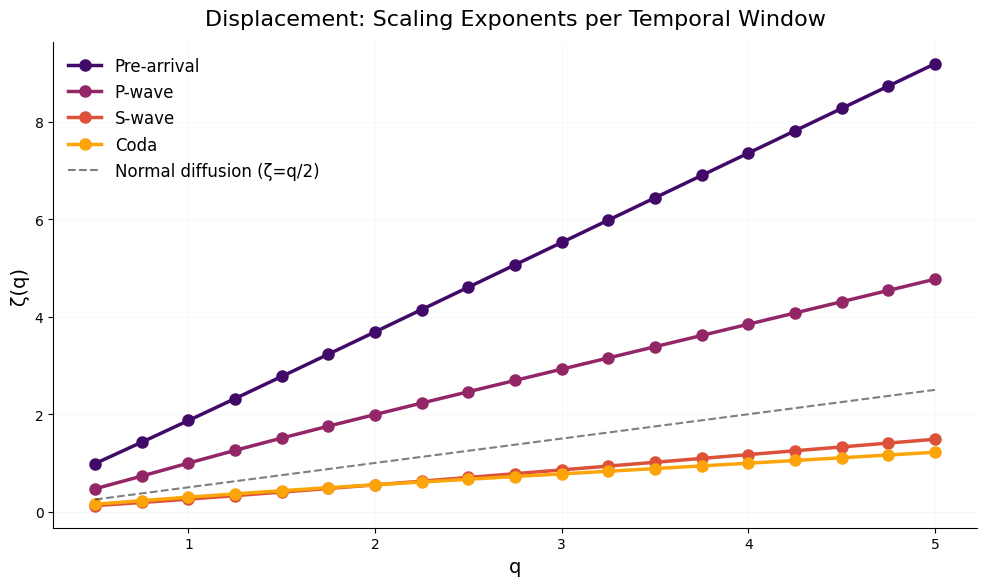

In [8]:
# Combine all displacement exponents
df_zeta_disp_all = pd.concat([
    results['displacement']['exponents']['pre_arrival'],
    results['displacement']['exponents']['p_wave'],
    results['displacement']['exponents']['s_wave'],
    results['displacement']['exponents']['coda']
], ignore_index=True)

# Plot
fig, ax = plt.subplots(figsize=(10, 6))

window_colors = {
    'pre_arrival': colors[0],
    'p_wave': colors[1],
    's_wave': colors[2],
    'coda': colors[3]
}

window_labels = {
    'pre_arrival': 'Pre-arrival',
    'p_wave': 'P-wave',
    's_wave': 'S-wave',
    'coda': 'Coda'
}

for window in ['pre_arrival', 'p_wave', 's_wave', 'coda']:
    df_w = df_zeta_disp_all[df_zeta_disp_all['window'] == window]
    if len(df_w) > 0:
        ax.plot(df_w['q'], df_w['zeta'], 'o-',
                color=window_colors[window],
                linewidth=2.5, markersize=8,
                label=window_labels[window])

# Reference: normal diffusion
q_ref = np.linspace(0.5, 5, 100)
ax.plot(q_ref, q_ref/2, '--', color='black', alpha=0.5,
        linewidth=1.5, label='Normal diffusion (ζ=q/2)')

ax.set_xlabel('q', fontsize=14)
ax.set_ylabel('ζ(q)', fontsize=14)
ax.set_title('Displacement: Scaling Exponents per Temporal Window', fontsize=16)
ax.legend(fontsize=12)
ax.grid(alpha=0.3)
plt.tight_layout()

# Save
filepath = FIGURES_DIR / 'displacement' / 'zeta_comparison_windows.pdf'
plt.savefig(filepath, bbox_inches='tight')
logger.info(f"Saved: {filepath}")

plt.show()

### 8.2 Displacement: Moments M_q(τ) for P-wave

Verify power-law scaling: $M_q(\tau) \sim \tau^{\zeta(q)}$

### 8.3 All processes: ζ(q) comparison for S-wave

Compare scaling behavior across acceleration, velocity, and displacement for S-wave window.

## 9. Summary

Create summary DataFrame with key results for each window and process.

In [9]:
summary_rows = []

for process in ['acceleration', 'velocity', 'displacement']:
    for window in ['pre_arrival', 'p_wave', 's_wave', 'coda']:
        df_zeta = results[process]['exponents'][window]
        df_mom = results[process]['moments'][window]
        
        if len(df_zeta) > 0:
            # Extract key metrics
            zeta_1 = df_zeta[df_zeta['q'] == 1.0]['zeta'].values[0] if 1.0 in df_zeta['q'].values else np.nan
            zeta_2 = df_zeta[df_zeta['q'] == 2.0]['zeta'].values[0] if 2.0 in df_zeta['q'].values else np.nan
            zeta_4 = df_zeta[df_zeta['q'] == 4.0]['zeta'].values[0] if 4.0 in df_zeta['q'].values else np.nan
            
            # Ensemble size
            n_stations = df_mom['n_stations'].iloc[0] if len(df_mom) > 0 else 0
            
            # Fit quality
            mean_r2 = df_zeta['r_squared'].mean()
            
            summary_rows.append({
                'process': process,
                'window': window,
                'n_stations': n_stations,
                'zeta_q1': zeta_1,
                'zeta_q2': zeta_2,
                'zeta_q4': zeta_4,
                'mean_r2': mean_r2
            })

df_summary = pd.DataFrame(summary_rows)

logger.info("\nSUMMARY TABLE:")
display(df_summary)

# Save
df_summary.to_parquet(DATA_DIR / 'summary_windowed_ensemble.parquet', index=False)
logger.info(f"\nSummary saved: {DATA_DIR / 'summary_windowed_ensemble.parquet'}")

INFO | 
SUMMARY TABLE:


,process,window,n_stations,zeta_q1,zeta_q2,zeta_q4,mean_r2
0,acceleration,pre_arrival,65,0.642274,1.158287,2.238547,0.511747
1,acceleration,p_wave,54,0.442813,0.917089,1.831136,0.531923
2,acceleration,s_wave,66,0.140608,0.296488,0.567384,0.247956
3,acceleration,coda,48,0.026574,0.051643,0.107425,0.094060
4,velocity,pre_arrival,65,1.013559,1.922816,3.757967,0.841294
5,velocity,p_wave,54,0.689593,1.364751,2.686311,0.692011
6,velocity,s_wave,66,-0.197066,-0.343319,-0.572732,0.329205
7,velocity,coda,48,0.122667,0.265302,0.600158,0.342333
8,displacement,pre_arrival,65,1.871098,3.690028,7.359174,0.970016
9,displacement,p_wave,54,0.997064,1.993904,3.847096,0.916772


INFO | 
Summary saved: ../data/processed/04b_moment_scaling/summary_windowed_ensemble.parquet
